# Heart Disease Prediction Project
**PJ — Предсказание сердечно-сосудистых заболеваний**

Автор: Constantine Rosljakov

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

## 1. Load the dataset

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (600000, 15)
Test shape: (400000, 14)


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


## 2. Preprocessing + One-Hot Encoding

In [4]:
for col in cat_cols:
    train_unique = set(train[col].unique())
    test_unique = set(test[col].unique())
    new_cats = test_unique - train_unique
    if new_cats:
        print(f"В колонке {col} есть новые категории в тесте: {new_cats}")

В колонке chest есть новые категории в тесте: {np.float64(0.987482), np.float64(1.1875), np.float64(2.824973), np.float64(2.384501), np.float64(1.926513), np.float64(1.740679), np.float64(1.962446), np.float64(2.143822), np.float64(2.078125), np.float64(1.578125), np.float64(1.609375), np.float64(2.015625), np.float64(3.096857), np.float64(1.821675), np.float64(2.124944), np.float64(1.268572), np.float64(1.331072), np.float64(1.44345), np.float64(1.740325), np.float64(1.19345), np.float64(1.81845), np.float64(1.7872), np.float64(1.437222), np.float64(1.665369), np.float64(1.277747), np.float64(1.637122), np.float64(1.871497), np.float64(1.865269), np.float64(1.959019), np.float64(2.130894), np.float64(2.115269), np.float64(2.2495), np.float64(1.258897), np.float64(1.212022), np.float64(1.383897), np.float64(1.268294), np.float64(1.490047), np.float64(1.943172), np.float64(1.452569), np.float64(2.155694), np.float64(1.399466), np.float64(0.384321), np.float64(0.721812), np.float64(0.935

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Фильтрация выбросов
train = train[train['age'] > 0]
train = train[train['resting_blood_pressure'] > 0]

# 5. Label Encoding для категориальных признаков
cat_cols = ['sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results',
            'exercise_induced_angina', 'slope', 'number_of_major_vessels', 'thal']

# ВАЖНО: создаем отдельный энкодер для каждой колонки
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# 6. Масштабирование числовых признаков
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 
            'maximum_heart_rate_achieved', 'oldpeak']

scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# 7. Разделение на признаки и целевую переменную
X_train = train.drop('class', axis=1)
y_train = train['class']
X_test = test

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Preprocessing completed!")

X_train shape: (600000, 14)
X_test shape: (400000, 14)
Preprocessing completed!


## 3. Анализ данных (Корреляция + Выбросы)

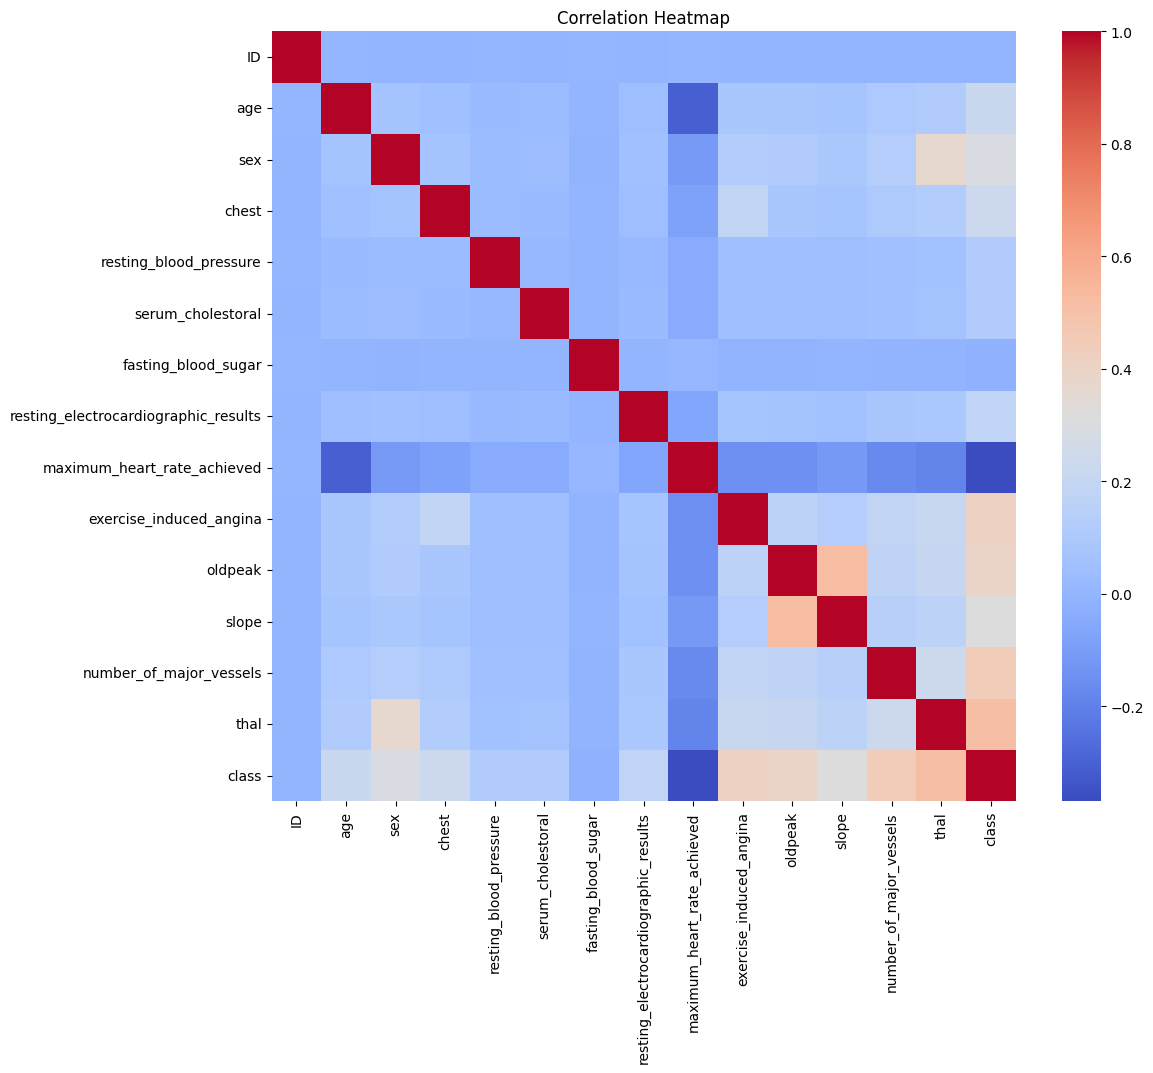

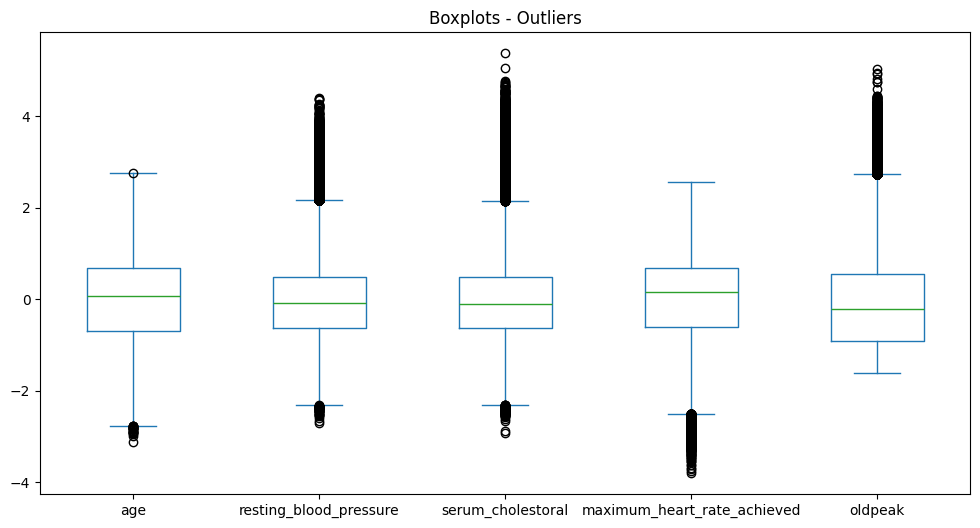

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

num_cols = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak']
train[num_cols].plot(kind='box', figsize=(12,6))
plt.title('Boxplots - Outliers')
plt.show()

## 4. Обучение моделей (Logistic Regression, Random Forest, Neural Network)

In [9]:
# ====================== 4. ОБУЧЕНИЕ МОДЕЛЕЙ ======================

# Подготовка данных
X = train.drop(['ID', 'class'], axis=1)
y = train['class']

X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=0.2, 
                                                  random_state=42, 
                                                  stratify=y)

# Масштабирование (нужно для Logistic Regression и Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Данные подготовлены к обучению!")
print(f"X_train shape: {X_train.shape}")

Данные подготовлены к обучению!
X_train shape: (480000, 13)


## Logistic Regression:

In [10]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_val_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_val, pred_lr))

Logistic Regression Accuracy: 0.869525


## Random Forest:

In [11]:

rf = RandomForestClassifier(n_estimators=300, 
                            max_depth=12, 
                            random_state=42, 
                            n_jobs=-1)
rf.fit(X_train, y_train)        
pred_rf = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, pred_rf))

Random Forest Accuracy: 0.89795


## Neural Network + график обучения:

In [12]:

class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = HeartDataset(X_train_scaled, y_train)
val_ds = HeartDataset(X_val_scaled, y_val)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)

class NN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.model(x)

model = NN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(25):
    # Train
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            outputs = model(Xb)
            val_loss += criterion(outputs, yb).item()
    val_losses.append(val_loss / len(val_loader))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:2d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

Epoch  0 | Train Loss: 0.2954 | Val Loss: 0.2777
Epoch  5 | Train Loss: 0.2721 | Val Loss: 0.2677
Epoch 10 | Train Loss: 0.2678 | Val Loss: 0.2640
Epoch 15 | Train Loss: 0.2651 | Val Loss: 0.2618
Epoch 20 | Train Loss: 0.2592 | Val Loss: 0.2550


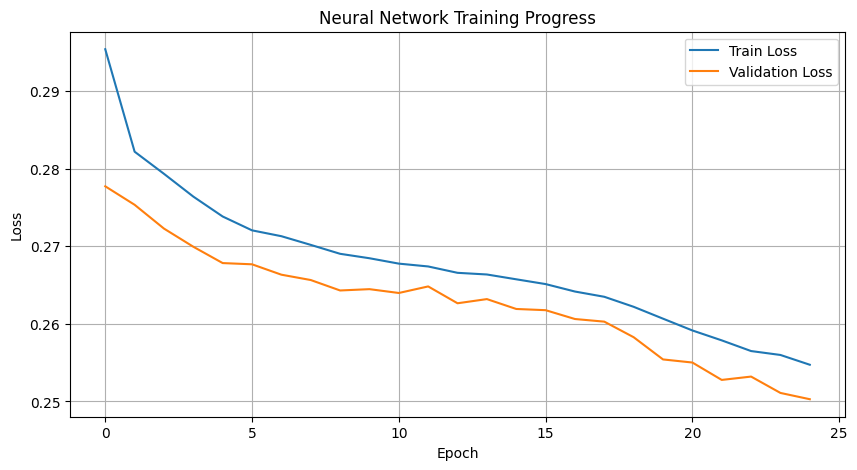

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Neural Network Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# ====================== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ======================

print("=== Результаты моделей на валидационной выборке ===")
print(f"Logistic Regression : {accuracy_score(y_val, pred_lr):.4f}")
print(f"Random Forest       : {accuracy_score(y_val, pred_rf):.4f}")

# Предсказание нейронной сети
model.eval()
with torch.no_grad():
    pred_nn = model(torch.tensor(X_val_scaled, dtype=torch.float32)).argmax(dim=1).numpy()

print(f"Neural Network      : {accuracy_score(y_val, pred_nn):.4f}")

=== Результаты моделей на валидационной выборке ===
Logistic Regression : 0.8695
Random Forest       : 0.8980
Neural Network      : 0.8967


In [15]:
# ====================== СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ======================

import joblib
import os

# Создаём папку models, если её нет
os.makedirs('../models', exist_ok=True)

# Сохраняем Random Forest (часто показывает хороший результат)
joblib.dump(rf, '../models/best_rf.pkl')

# Сохраняем Neural Network
torch.save(model.state_dict(), '../models/best_nn.pth')

print("Модели успешно сохранены!")
print("Сохранено:")
print("   - ../models/best_rf.pkl")
print("   - ../models/best_nn.pth")

Модели успешно сохранены!
Сохранено:
   - ../models/best_rf.pkl
   - ../models/best_nn.pth
